In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv("../data/transactions.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully
Shape: (50000, 16)

Columns:
['transaction_id', 'customer_id', 'transaction_amount', 'transaction_time', 'payment_method', 'product_category', 'customer_age', 'account_age_days', 'device_type', 'customer_location', 'previous_transaction_count', 'failed_transaction_count', 'is_new_device', 'is_new_location', 'night_transaction', 'is_fraud']


In [3]:
df.head()

,transaction_id,customer_id,transaction_amount,transaction_time,payment_method,product_category,customer_age,account_age_days,device_type,customer_location,previous_transaction_count,failed_transaction_count,is_new_device,is_new_location,night_transaction,is_fraud
0,TXN000001,CUST8270,738.33,2026-01-01 00:00:00,Net Banking,Sports,65,785,Desktop,Kolkata,26,9,0,0,0,0
1,TXN000002,CUST1860,225.84,2026-01-01 00:10:00,Wallet,Home,38,100,Tablet,Bhubaneswar,98,4,0,0,0,0
2,TXN000003,CUST6390,877.63,2026-01-01 00:20:00,Debit Card,Sports,25,2339,Tablet,Bhubaneswar,54,9,0,0,0,0
3,TXN000004,CUST6191,437.25,2026-01-01 00:30:00,Net Banking,Beauty,35,934,Tablet,Bhubaneswar,0,1,0,0,0,0
4,TXN000005,CUST6734,803.86,2026-01-01 00:40:00,Net Banking,Electronics,35,812,Desktop,Chennai,47,1,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transaction_id              50000 non-null  str    
 1   customer_id                 50000 non-null  str    
 2   transaction_amount          50000 non-null  float64
 3   transaction_time            50000 non-null  str    
 4   payment_method              50000 non-null  str    
 5   product_category            50000 non-null  str    
 6   customer_age                50000 non-null  int64  
 7   account_age_days            50000 non-null  int64  
 8   device_type                 50000 non-null  str    
 9   customer_location           50000 non-null  str    
 10  previous_transaction_count  50000 non-null  int64  
 11  failed_transaction_count    50000 non-null  int64  
 12  is_new_device               50000 non-null  int64  
 13  is_new_location             50000 non-null

In [5]:
df.isnull().sum()

transaction_id                0
customer_id                   0
transaction_amount            0
transaction_time              0
payment_method                0
product_category              0
customer_age                  0
account_age_days              0
device_type                   0
customer_location             0
previous_transaction_count    0
failed_transaction_count      0
is_new_device                 0
is_new_location               0
night_transaction             0
is_fraud                      0
dtype: int64

In [6]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [7]:
print(df["is_fraud"].value_counts())

is_fraud
0    36653
1    13347
Name: count, dtype: int64


In [8]:
fraud_percentage = df["is_fraud"].mean() * 100

print(f"Fraud transactions: {fraud_percentage:.2f}%")
print(f"Non-fraud transactions: {100 - fraud_percentage:.2f}%")

Fraud transactions: 26.69%
Non-fraud transactions: 73.31%


In [9]:
df.describe()

,transaction_amount,customer_age,account_age_days,previous_transaction_count,failed_transaction_count,is_new_device,is_new_location,night_transaction,is_fraud
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,810.057081,43.464960,1248.326860,49.56578,4.484000,0.147820,0.120900,0.250900,0.266940
std,1042.877430,15.065299,719.097374,28.91276,2.877622,0.354925,0.326014,0.433535,0.442365
min,8.160000,18.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,251.877500,30.000000,627.000000,25.00000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,491.815000,43.000000,1247.000000,49.00000,4.000000,0.000000,0.000000,0.000000,0.000000
75%,966.362500,57.000000,1866.000000,75.00000,7.000000,0.000000,0.000000,1.000000,1.000000
max,24342.120000,69.000000,2499.000000,99.00000,9.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"])

print("Transaction time converted successfully")
print(df["transaction_time"].dtype)

Transaction time converted successfully
datetime64[us]


In [11]:
df["transaction_hour"] = df["transaction_time"].dt.hour

print("Transaction hour created successfully")
print(df[["transaction_time", "transaction_hour"]].head())

Transaction hour created successfully
     transaction_time  transaction_hour
0 2026-01-01 00:00:00                 0
1 2026-01-01 00:10:00                 0
2 2026-01-01 00:20:00                 0
3 2026-01-01 00:30:00                 0
4 2026-01-01 00:40:00                 0


In [12]:
fraud_by_hour = df.groupby("transaction_hour")["is_fraud"].mean() * 100

print("Fraud percentage by hour:")
print(fraud_by_hour)

Fraud percentage by hour:
transaction_hour
0     25.047893
1     27.298851
2     27.825670
3     26.532567
4     26.388889
5     25.959693
6     27.713737
7     26.272815
8     27.089337
9     28.049952
10    24.831892
11    26.368876
12    26.224784
13    25.360231
14    27.041306
15    27.185399
16    28.290106
17    26.032661
18    26.609030
19    28.674352
20    25.696446
21    27.665706
22    25.744476
23    26.753122
Name: is_fraud, dtype: float64


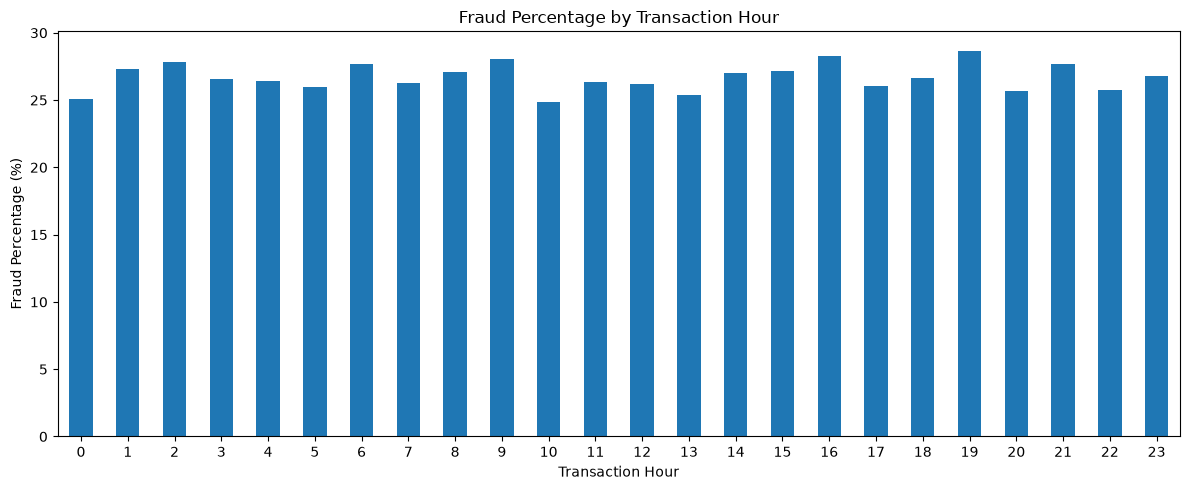

In [14]:
plt.figure(figsize=(12, 5))

fraud_by_hour.plot(kind="bar")

plt.title("Fraud Percentage by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
night_fraud = df.groupby("night_transaction")["is_fraud"].mean() * 100

print("Fraud percentage by night transaction:")
print(night_fraud)

Fraud percentage by night transaction:
night_transaction
0    23.089040
1    37.457154
Name: is_fraud, dtype: float64


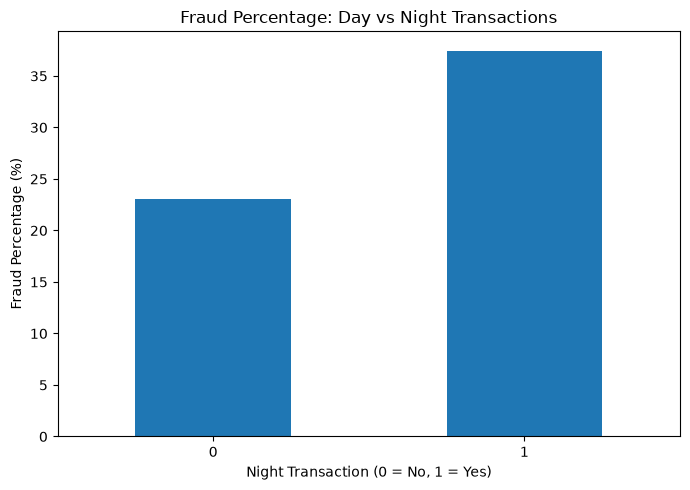

In [16]:
plt.figure(figsize=(7, 5))

night_fraud.plot(kind="bar")

plt.title("Fraud Percentage: Day vs Night Transactions")
plt.xlabel("Night Transaction (0 = No, 1 = Yes)")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
amount_fraud = df.groupby("is_fraud")["transaction_amount"].mean()

print("Average transaction amount:")
print(amount_fraud)

Average transaction amount:
is_fraud
0     508.444935
1    1638.332347
Name: transaction_amount, dtype: float64


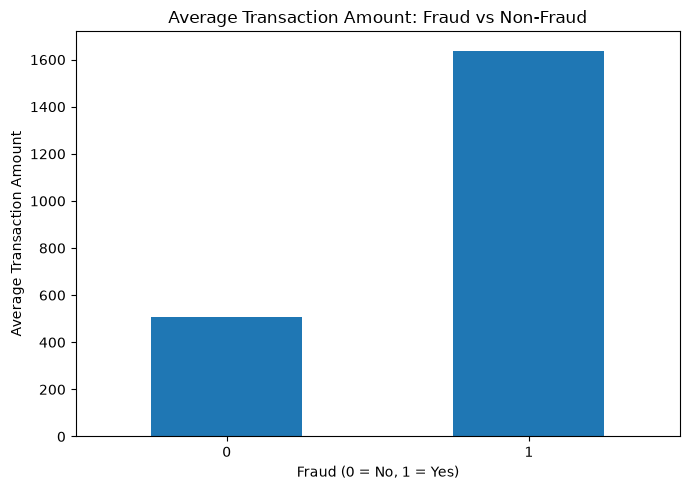

In [18]:
plt.figure(figsize=(7, 5))

amount_fraud.plot(kind="bar")

plt.title("Average Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
payment_fraud = df.groupby("payment_method")["is_fraud"].mean() * 100

print("Fraud percentage by payment method:")
print(payment_fraud)

Fraud percentage by payment method:
payment_method
Credit Card    26.759721
Debit Card     26.648708
Net Banking    26.934985
UPI            26.706083
Wallet         26.418885
Name: is_fraud, dtype: float64


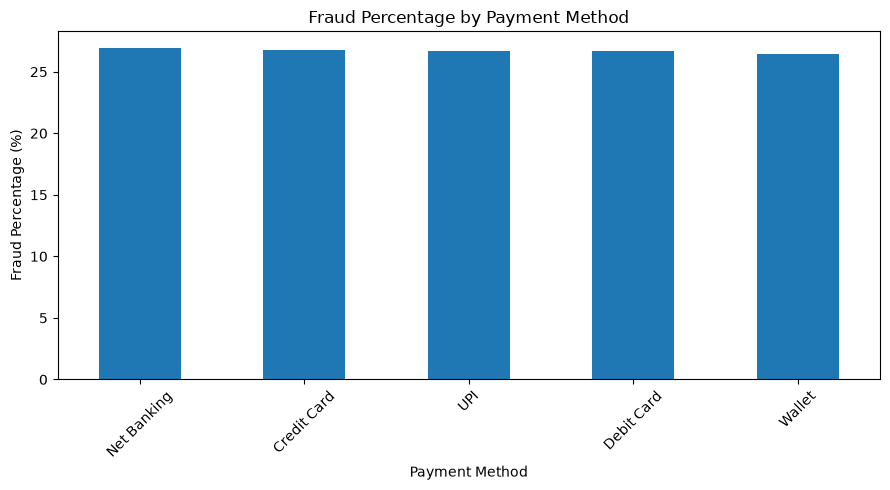

In [20]:
plt.figure(figsize=(9, 5))

payment_fraud.sort_values(ascending=False).plot(kind="bar")

plt.title("Fraud Percentage by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
category_fraud = df.groupby("product_category")["is_fraud"].mean() * 100

print("Fraud percentage by product category:")
print(category_fraud)

Fraud percentage by product category:
product_category
Beauty         27.115592
Clothing       27.129226
Electronics    25.973072
Grocery        26.490784
Home           26.909784
Sports         26.520798
Name: is_fraud, dtype: float64


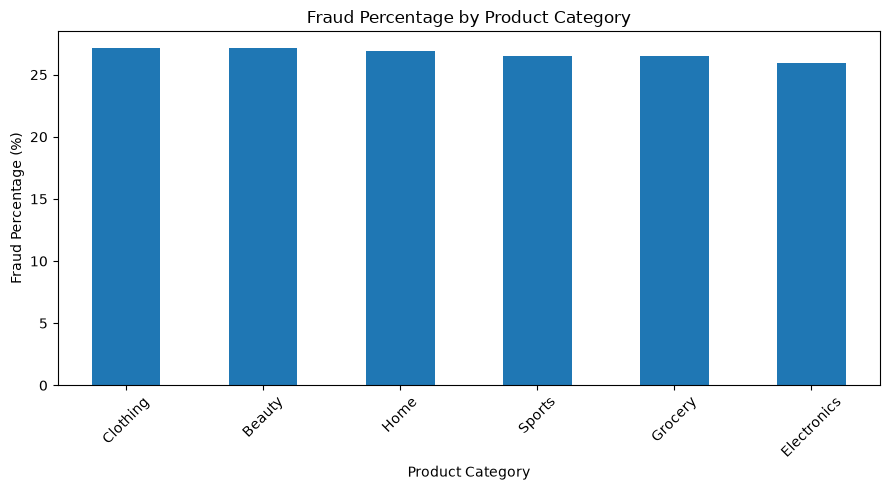

In [22]:
plt.figure(figsize=(9, 5))

category_fraud.sort_values(ascending=False).plot(kind="bar")

plt.title("Fraud Percentage by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
device_fraud = df.groupby("device_type")["is_fraud"].mean() * 100

print("Fraud percentage by device type:")
print(device_fraud)

Fraud percentage by device type:
device_type
Desktop    26.342110
Mobile     26.783584
Tablet     26.954745
Name: is_fraud, dtype: float64


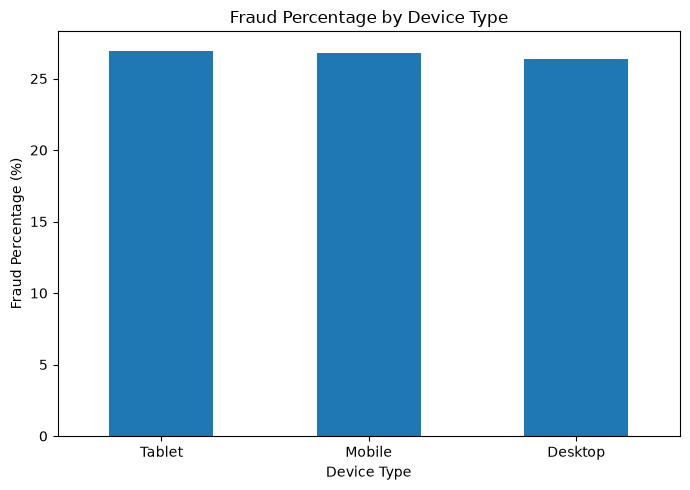

In [24]:
plt.figure(figsize=(7, 5))

device_fraud.sort_values(ascending=False).plot(kind="bar")

plt.title("Fraud Percentage by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
location_fraud = df.groupby("customer_location")["is_fraud"].mean() * 100

print("Fraud percentage by customer location:")
print(location_fraud.sort_values(ascending=False))

Fraud percentage by customer location:
customer_location
Hyderabad      27.488527
Bangalore      27.306999
Kolkata        27.067183
Pune           27.038965
Bhubaneswar    26.974952
Mumbai         26.378897
Chennai        25.682621
Delhi          25.630915
Name: is_fraud, dtype: float64


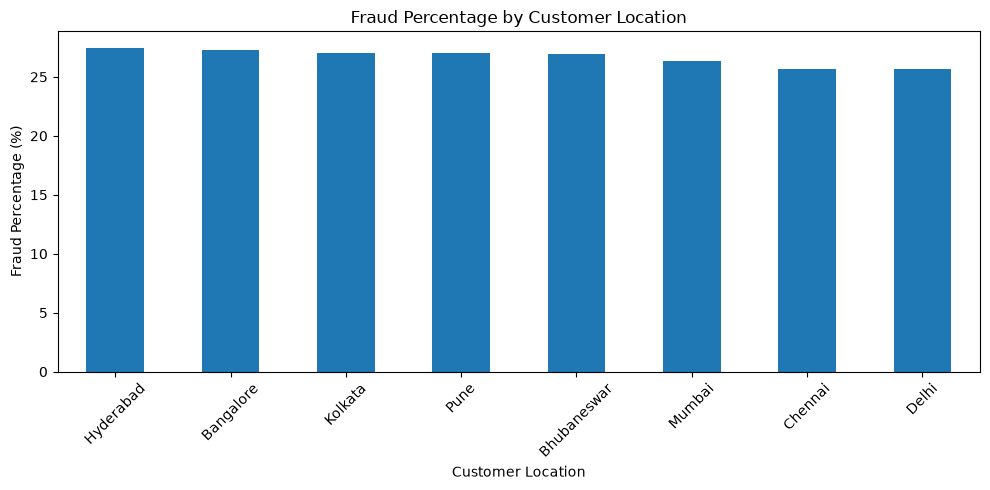

In [26]:
plt.figure(figsize=(10, 5))

location_fraud.sort_values(ascending=False).plot(kind="bar")

plt.title("Fraud Percentage by Customer Location")
plt.xlabel("Customer Location")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
risk_features = [
    "is_new_device",
    "is_new_location",
    "night_transaction"
]

for feature in risk_features:
    result = df.groupby(feature)["is_fraud"].mean() * 100
    
    print("\n", feature)
    print(result)


 is_new_device
is_new_device
0    23.145345
1    47.151942
Name: is_fraud, dtype: float64

 is_new_location
is_new_location
0    23.908543
1    46.947891
Name: is_fraud, dtype: float64

 night_transaction
night_transaction
0    23.089040
1    37.457154
Name: is_fraud, dtype: float64


In [28]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['transaction_amount', 'customer_age', 'account_age_days', 'previous_transaction_count', 'failed_transaction_count', 'is_new_device', 'is_new_location', 'night_transaction', 'is_fraud']


In [29]:
fraud_correlation = (
    df[numerical_columns]
    .corr()["is_fraud"]
    .sort_values(ascending=False)
)

print("Correlation with fraud:")
print(fraud_correlation)

Correlation with fraud:
is_fraud                      1.000000
transaction_amount            0.479273
failed_transaction_count      0.229345
is_new_device                 0.192613
is_new_location               0.169795
night_transaction             0.140813
previous_transaction_count    0.004049
customer_age                 -0.002848
account_age_days             -0.010749
Name: is_fraud, dtype: float64


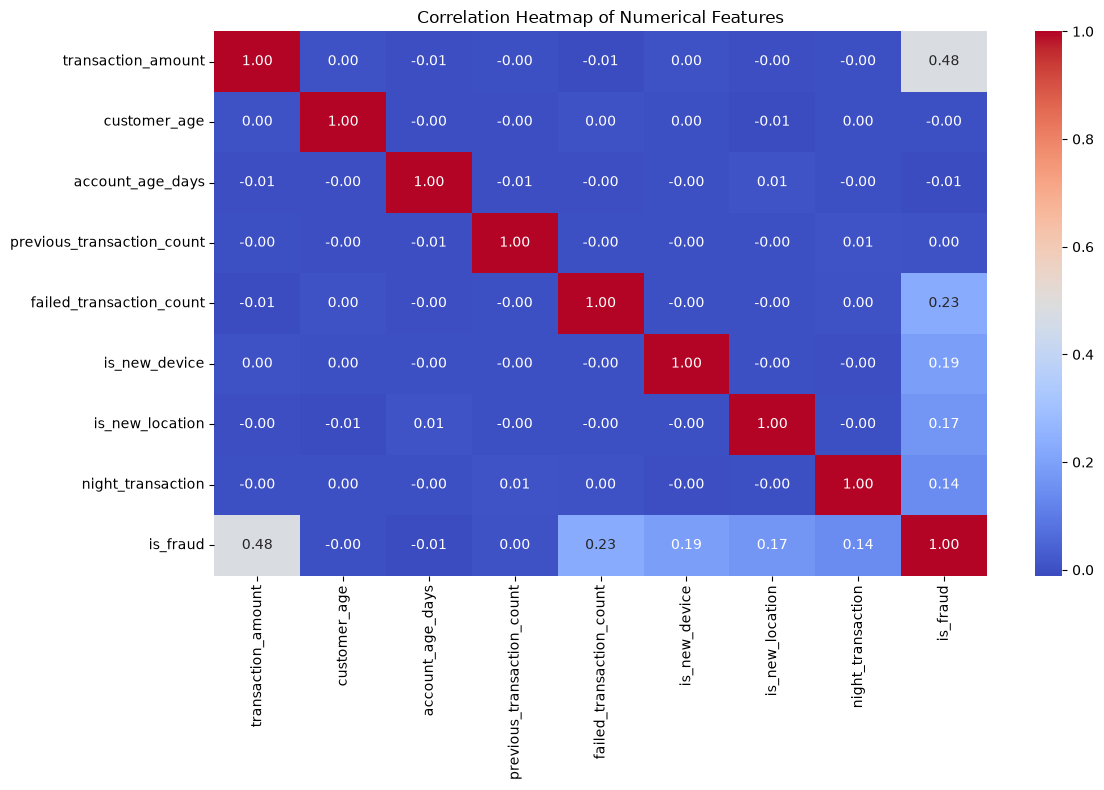

In [30]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

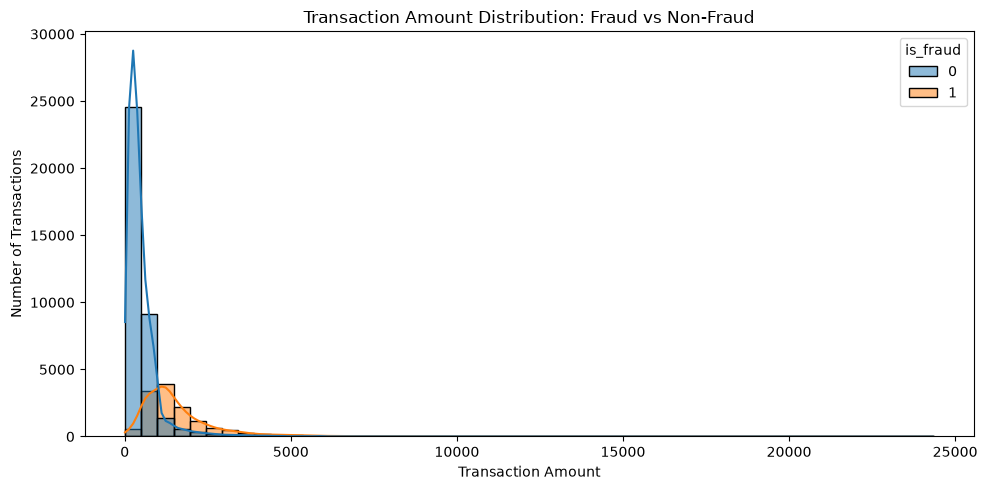

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="transaction_amount",
    hue="is_fraud",
    bins=50,
    kde=True
)

plt.title("Transaction Amount Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [32]:
failed_fraud = df.groupby("failed_transaction_count")["is_fraud"].mean() * 100

print("Fraud percentage by failed transaction count:")
print(failed_fraud)

Fraud percentage by failed transaction count:
failed_transaction_count
0     7.205624
1     7.255139
2     6.975358
3    35.789474
4    35.199679
5    35.032103
6    34.958527
7    35.522570
8    35.064166
9    34.577365
Name: is_fraud, dtype: float64


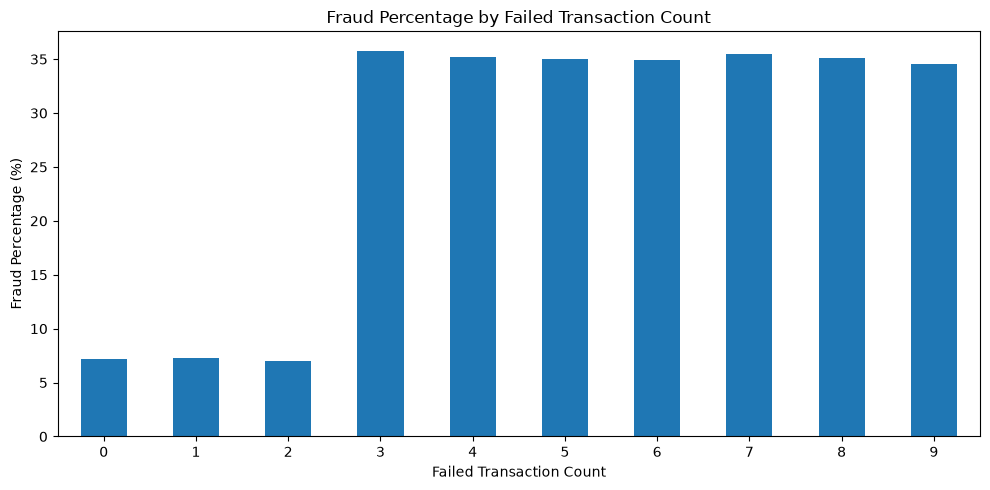

In [33]:
plt.figure(figsize=(10, 5))

failed_fraud.plot(kind="bar")

plt.title("Fraud Percentage by Failed Transaction Count")
plt.xlabel("Failed Transaction Count")
plt.ylabel("Fraud Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
device_location_fraud = (
    df.groupby(["is_new_device", "is_new_location"])["is_fraud"]
    .mean() * 100
)

print("Fraud percentage by new device and new location:")
print(device_location_fraud)

Fraud percentage by new device and new location:
is_new_device  is_new_location
0              0                  20.513231
               1                  42.248062
1              0                  43.452198
               1                  74.350282
Name: is_fraud, dtype: float64


In [35]:
print("EDA COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Dataset shape:", df.shape)
print("Total transactions:", len(df))
print("Total fraud transactions:", df["is_fraud"].sum())
print("Fraud rate:", round(df["is_fraud"].mean() * 100, 2), "%")
print("Total numerical features:", len(numerical_columns))

EDA COMPLETED SUCCESSFULLY
----------------------------------------
Dataset shape: (50000, 17)
Total transactions: 50000
Total fraud transactions: 13347
Fraud rate: 26.69 %
Total numerical features: 9


In [36]:
df["amount_log"] = np.log1p(df["transaction_amount"])

print("amount_log created successfully")
print(df[["transaction_amount", "amount_log"]].head())

amount_log created successfully
   transaction_amount  amount_log
0              738.33    6.605744
1              225.84    5.424245
2              877.63    6.778364
3              437.25    6.082790
4              803.86    6.690668


In [37]:
df["failure_rate"] = (
    df["failed_transaction_count"] /
    (df["previous_transaction_count"] + 1)
)

print("failure_rate created successfully")
print(df[["failed_transaction_count",
          "previous_transaction_count",
          "failure_rate"]].head())

failure_rate created successfully
   failed_transaction_count  previous_transaction_count  failure_rate
0                         9                          26      0.333333
1                         4                          98      0.040404
2                         9                          54      0.163636
3                         1                           0      1.000000
4                         1                          47      0.020833


In [38]:
customer_avg = df.groupby("customer_id")["transaction_amount"].transform("mean")

df["customer_avg_amount"] = customer_avg

print("customer_avg_amount created successfully")
print(df[["customer_id",
          "transaction_amount",
          "customer_avg_amount"]].head())

customer_avg_amount created successfully
  customer_id  transaction_amount  customer_avg_amount
0    CUST8270              738.33           496.585000
1    CUST1860              225.84           708.543333
2    CUST6390              877.63          1099.600000
3    CUST6191              437.25           796.145556
4    CUST6734              803.86           637.322500


In [39]:
df["amount_deviation"] = (
    df["transaction_amount"] /
    (df["customer_avg_amount"] + 1)
)

print("amount_deviation created successfully")
print(df[["transaction_amount",
          "customer_avg_amount",
          "amount_deviation"]].head())

amount_deviation created successfully
   transaction_amount  customer_avg_amount  amount_deviation
0              738.33           496.585000          1.483827
1              225.84           708.543333          0.318289
2              877.63          1099.600000          0.797411
3              437.25           796.145556          0.548520
4              803.86           637.322500          1.259332


In [40]:
df["risk_signal_score"] = (
    (df["is_new_device"] * 1.0) +
    (df["is_new_location"] * 1.0) +
    (df["night_transaction"] * 0.5) +
    (df["failure_rate"] * 2.0) +
    ((df["transaction_amount"] > 500) * 1.0) +
    ((df["transaction_amount"] > 1000) * 1.0)
)

print("risk_signal_score created successfully")
print(df[["is_new_device",
          "is_new_location",
          "night_transaction",
          "failure_rate",
          "transaction_amount",
          "risk_signal_score"]].head())

risk_signal_score created successfully
   is_new_device  is_new_location  night_transaction  failure_rate  \
0              0                0                  0      0.333333   
1              0                0                  0      0.040404   
2              0                0                  0      0.163636   
3              0                0                  0      1.000000   
4              0                0                  0      0.020833   

   transaction_amount  risk_signal_score  
0              738.33           1.666667  
1              225.84           0.080808  
2              877.63           1.327273  
3              437.25           2.000000  
4              803.86           1.041667  


In [41]:
new_features = [
    "transaction_hour",
    "amount_log",
    "failure_rate",
    "customer_avg_amount",
    "amount_deviation",
    "risk_signal_score"
]

print("New features:")
print(new_features)

print("\nDataset shape:")
print(df.shape)

New features:
['transaction_hour', 'amount_log', 'failure_rate', 'customer_avg_amount', 'amount_deviation', 'risk_signal_score']

Dataset shape:
(50000, 22)


In [42]:
print("Missing values in new features:")
print(df[new_features].isnull().sum())

Missing values in new features:
transaction_hour       0
amount_log             0
failure_rate           0
customer_avg_amount    0
amount_deviation       0
risk_signal_score      0
dtype: int64


In [43]:
df.to_csv("../data/transactions_featured.csv", index=False)

print("Feature-engineered dataset saved successfully!")

Feature-engineered dataset saved successfully!


In [44]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (50000, 22)
Columns:
['transaction_id', 'customer_id', 'transaction_amount', 'transaction_time', 'payment_method', 'product_category', 'customer_age', 'account_age_days', 'device_type', 'customer_location', 'previous_transaction_count', 'failed_transaction_count', 'is_new_device', 'is_new_location', 'night_transaction', 'is_fraud', 'transaction_hour', 'amount_log', 'failure_rate', 'customer_avg_amount', 'amount_deviation', 'risk_signal_score']


In [45]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 21)
Target shape: (50000,)


In [46]:
print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Target distribution:
is_fraud
0    36653
1    13347
Name: count, dtype: int64

Target percentage:
is_fraud
0    73.31
1    26.69
Name: proportion, dtype: float64


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test split completed successfully!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Train/Test split completed successfully!
X_train: (40000, 21)
X_test: (10000, 21)
y_train: (40000,)
y_test: (10000,)


In [48]:
print("Training fraud rate:",
      round(y_train.mean() * 100, 2), "%")

print("Testing fraud rate:",
      round(y_test.mean() * 100, 2), "%")

Training fraud rate: 26.7 %
Testing fraud rate: 26.69 %


In [49]:
print("STEP 11 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Total samples:", len(df))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", X_train.shape[1])

STEP 11 COMPLETED SUCCESSFULLY
----------------------------------------
Total samples: 50000
Training samples: 40000
Testing samples: 10000
Number of features: 21


In [50]:
# Remove ID and raw datetime columns
X_model = X.drop(
    columns=["transaction_id", "customer_id", "transaction_time"]
)

print("Model features prepared successfully!")
print("X_model shape:", X_model.shape)
print("\nRemaining columns:")
print(X_model.columns.tolist())

Model features prepared successfully!
X_model shape: (50000, 18)

Remaining columns:
['transaction_amount', 'payment_method', 'product_category', 'customer_age', 'account_age_days', 'device_type', 'customer_location', 'previous_transaction_count', 'failed_transaction_count', 'is_new_device', 'is_new_location', 'night_transaction', 'transaction_hour', 'amount_log', 'failure_rate', 'customer_avg_amount', 'amount_deviation', 'risk_signal_score']


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test split completed!")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Train/Test split completed!
X_train: (40000, 18)
X_test: (10000, 18)
y_train: (40000,)
y_test: (10000,)


In [53]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["str"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['transaction_amount', 'customer_age', 'account_age_days', 'previous_transaction_count', 'failed_transaction_count', 'is_new_device', 'is_new_location', 'night_transaction', 'amount_log', 'failure_rate', 'customer_avg_amount', 'amount_deviation', 'risk_signal_score']

Categorical features:
['payment_method', 'product_category', 'device_type', 'customer_location']


In [54]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessing pipeline created successfully!")

Numerical preprocessing pipeline created successfully!


In [55]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

print("Categorical preprocessing pipeline created successfully!")

Categorical preprocessing pipeline created successfully!


In [56]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [57]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Preprocessing completed successfully!
Processed X_train shape: (40000, 35)
Processed X_test shape: (10000, 35)


In [58]:
print("STEP 12 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Original features:", X.shape[1])
print("Model features:", X_model.shape[1])
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

STEP 12 COMPLETED SUCCESSFULLY
----------------------------------------
Original features: 21
Model features: 18
Numerical features: 13
Categorical features: 4
Processed training shape: (40000, 35)
Processed testing shape: (10000, 35)


In [59]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [61]:
from sklearn.pipeline import Pipeline

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

print("Baseline model created successfully!")

Baseline model created successfully!


In [62]:
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [63]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 10000


In [64]:
y_proba = baseline_model.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated successfully!")
print("First 10 fraud probabilities:")
print(y_proba[:10])

Prediction probabilities generated successfully!
First 10 fraud probabilities:
[6.01761700e-03 7.37932829e-04 1.24659761e-03 7.28179730e-03
 9.96787302e-01 9.24530556e-01 4.05176669e-01 7.01007438e-01
 4.97659295e-02 2.57971482e-01]


In [65]:
print("STEP 13 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Model:", "Logistic Regression")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Predictions:", len(y_pred))

STEP 13 COMPLETED SUCCESSFULLY
----------------------------------------
Model: Logistic Regression
Training samples: 40000
Testing samples: 10000
Predictions: 10000


In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [67]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("MODEL PERFORMANCE")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

MODEL PERFORMANCE
----------------------------------------
Accuracy  : 0.9434
Precision : 0.8444
Recall    : 0.9659
F1 Score  : 0.9011
ROC-AUC   : 0.9814


In [68]:
print("CLASSIFICATION REPORT")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Fraud", "Fraud"]
    )
)

CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.94      0.96      7331
       Fraud       0.84      0.97      0.90      2669

    accuracy                           0.94     10000
   macro avg       0.92      0.95      0.93     10000
weighted avg       0.95      0.94      0.94     10000



In [69]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6856  475]
 [  91 2578]]


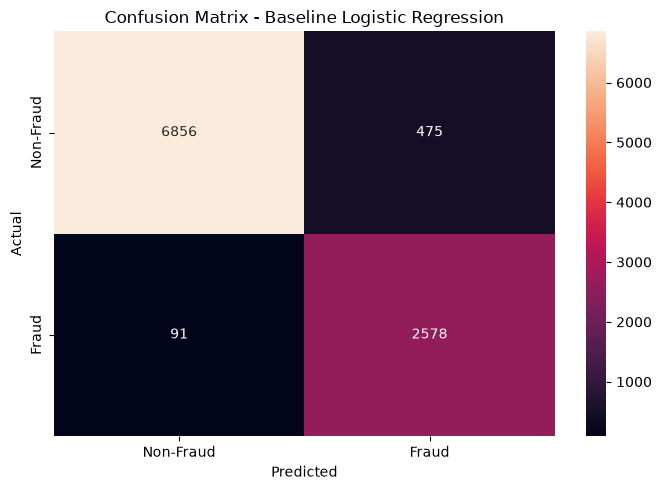

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

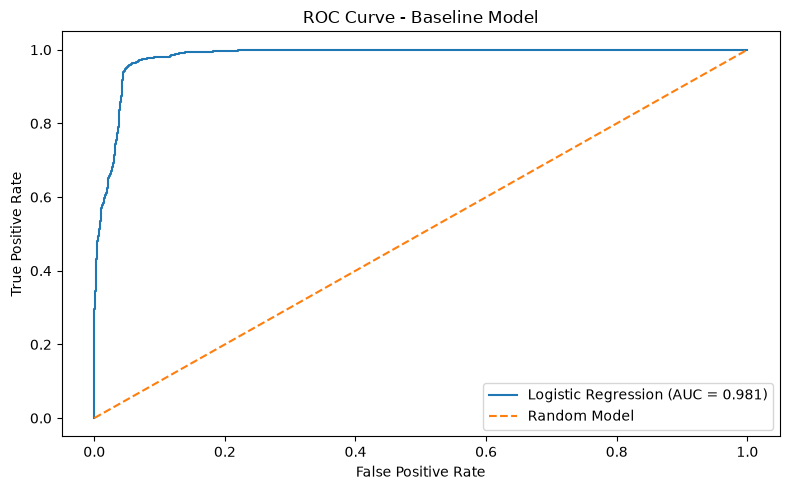

In [71]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.title("ROC Curve - Baseline Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
print("STEP 14 COMPLETED SUCCESSFULLY")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

STEP 14 COMPLETED SUCCESSFULLY
----------------------------------------
Accuracy  : 0.9434
Precision : 0.8444
Recall    : 0.9659
F1 Score  : 0.9011
ROC-AUC   : 0.9814


In [73]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [74]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [75]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [76]:
rf_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(rf_pred))

Random Forest predictions generated successfully!
Number of predictions: 10000


In [77]:
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest probabilities generated successfully!")
print("First 10 probabilities:")
print(rf_proba[:10])

Random Forest probabilities generated successfully!
First 10 probabilities:
[1.39853714e-01 0.00000000e+00 2.73972603e-05 1.27321603e-02
 9.98596063e-01 1.43794425e-01 2.20592323e-02 9.72278305e-01
 2.49252409e-02 2.48845044e-01]


In [78]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("RANDOM FOREST PERFORMANCE")
print("-" * 40)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

RANDOM FOREST PERFORMANCE
----------------------------------------
Accuracy  : 0.9636
Precision : 0.8962
Recall    : 0.9768
F1 Score  : 0.9347
ROC-AUC   : 0.9961


In [79]:
print("RANDOM FOREST CLASSIFICATION REPORT")
print("-" * 40)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Non-Fraud", "Fraud"]
    )
)

RANDOM FOREST CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.96      0.97      7331
       Fraud       0.90      0.98      0.93      2669

    accuracy                           0.96     10000
   macro avg       0.94      0.97      0.95     10000
weighted avg       0.97      0.96      0.96     10000



In [80]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[7029  302]
 [  62 2607]]


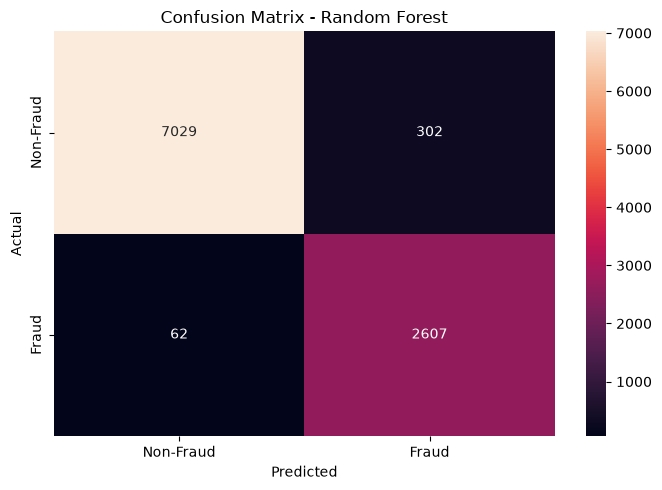

In [81]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [82]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9434,0.844415,0.965905,0.901084,0.981414
1,Random Forest,0.9636,0.896184,0.976770,0.934744,0.996074


In [83]:
print("STEP 15 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Models trained: 2")
print("1. Logistic Regression")
print("2. Random Forest")
print("Random Forest ROC-AUC:", round(rf_roc_auc, 4))

STEP 15 COMPLETED SUCCESSFULLY
----------------------------------------
Models trained: 2
1. Logistic Regression
2. Random Forest
Random Forest ROC-AUC: 0.9961


In [84]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9434,0.844415,0.965905,0.901084,0.981414
1,Random Forest,0.9636,0.896184,0.976770,0.934744,0.996074


In [85]:
if rf_roc_auc > roc_auc:
    best_model = random_forest_model
    best_model_name = "Random Forest"
    best_roc_auc = rf_roc_auc
else:
    best_model = baseline_model
    best_model_name = "Logistic Regression"
    best_roc_auc = roc_auc

print("BEST MODEL SELECTED")
print("-" * 40)
print("Model:", best_model_name)
print("ROC-AUC:", round(best_roc_auc, 4))

BEST MODEL SELECTED
----------------------------------------
Model: Random Forest
ROC-AUC: 0.9961


In [86]:
if best_model_name == "Random Forest":
    best_pred = rf_pred
    best_proba = rf_proba
else:
    best_pred = y_pred
    best_proba = y_proba

best_accuracy = accuracy_score(y_test, best_pred)
best_precision = precision_score(y_test, best_pred)
best_recall = recall_score(y_test, best_pred)
best_f1 = f1_score(y_test, best_pred)
best_roc_auc = roc_auc_score(y_test, best_proba)

print("BEST MODEL PERFORMANCE")
print("-" * 40)
print(f"Model     : {best_model_name}")
print(f"Accuracy  : {best_accuracy:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")
print(f"F1 Score  : {best_f1:.4f}")
print(f"ROC-AUC   : {best_roc_auc:.4f}")

BEST MODEL PERFORMANCE
----------------------------------------
Model     : Random Forest
Accuracy  : 0.9636
Precision : 0.8962
Recall    : 0.9768
F1 Score  : 0.9347
ROC-AUC   : 0.9961


In [87]:
best_cm = confusion_matrix(y_test, best_pred)

print("Best Model Confusion Matrix:")
print(best_cm)

Best Model Confusion Matrix:
[[7029  302]
 [  62 2607]]


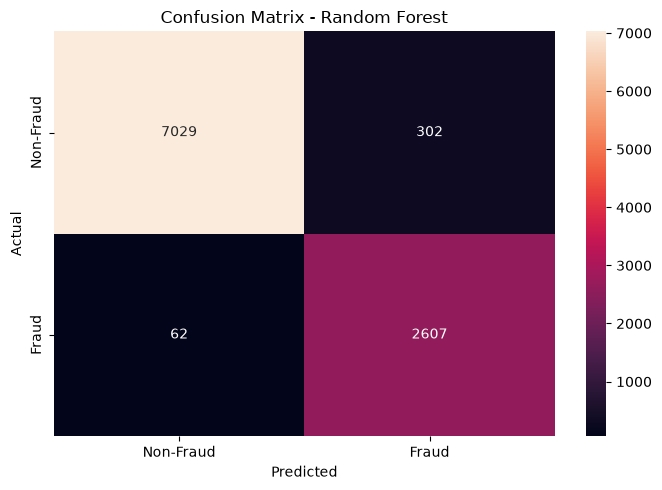

In [88]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [89]:
print("STEP 16 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Best Model:", best_model_name)
print("Accuracy:", round(best_accuracy, 4))
print("Precision:", round(best_precision, 4))
print("Recall:", round(best_recall, 4))
print("F1 Score:", round(best_f1, 4))
print("ROC-AUC:", round(best_roc_auc, 4))

STEP 16 COMPLETED SUCCESSFULLY
----------------------------------------
Best Model: Random Forest
Accuracy: 0.9636
Precision: 0.8962
Recall: 0.9768
F1 Score: 0.9347
ROC-AUC: 0.9961


In [90]:
import joblib

print("Joblib imported successfully!")

Joblib imported successfully!


In [91]:
model_path = "../models/fraud_detection_model.pkl"

joblib.dump(best_model, model_path)

print("Best model saved successfully!")
print("Model path:", model_path)

Best model saved successfully!
Model path: ../models/fraud_detection_model.pkl


In [92]:
import os

print("Model file exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Model file size:",
          round(os.path.getsize(model_path) / 1024, 2),
          "KB")

Model file exists: True
Model file size: 27562.68 KB


In [93]:
loaded_model = joblib.load(model_path)

print("Saved model loaded successfully!")
print("Loaded model type:", type(loaded_model))

Saved model loaded successfully!
Loaded model type: <class 'sklearn.pipeline.Pipeline'>


In [94]:
test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Prediction test successful!")
print("First 5 predictions:", test_prediction)

Prediction test successful!
First 5 predictions: [0 0 0 0 1]


In [95]:
print("STEP 17 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Best Model:", best_model_name)
print("Model saved at:", model_path)
print("Model file exists:", os.path.exists(model_path))
print("Model reload successful:", type(loaded_model).__name__)

STEP 17 COMPLETED SUCCESSFULLY
----------------------------------------
Best Model: Random Forest
Model saved at: ../models/fraud_detection_model.pkl
Model file exists: True
Model reload successful: Pipeline


In [96]:
import joblib

model_path = "../models/fraud_detection_model.pkl"

loaded_model = joblib.load(model_path)

print("Fraud detection model loaded successfully!")

Fraud detection model loaded successfully!


In [97]:
def predict_fraud(transaction_data):
    """
    Predict whether a transaction is fraudulent.
    """

    prediction = loaded_model.predict(transaction_data)[0]
    probability = loaded_model.predict_proba(transaction_data)[0][1]

    if prediction == 1:
        result = "FRAUD"
    else:
        result = "NON-FRAUD"

    return result, probability

In [98]:
print("Fraud prediction function created successfully!")

Fraud prediction function created successfully!


In [99]:
sample_transaction = pd.DataFrame([{
    "transaction_amount": 1200.50,
    "payment_method": "Credit Card",
    "product_category": "Electronics",
    "customer_age": 25,
    "account_age_days": 15,
    "device_type": "Mobile",
    "customer_location": "Bhubaneswar",
    "previous_transaction_count": 5,
    "failed_transaction_count": 4,
    "is_new_device": 1,
    "is_new_location": 1,
    "night_transaction": 1,
    "transaction_hour": 2,
    "amount_log": np.log1p(1200.50),
    "failure_rate": 4 / (5 + 1),
    "customer_avg_amount": 300.0,
    "amount_deviation": 1200.50 / (300.0 + 1),
    "risk_signal_score": 0
}])

print("Sample transaction created successfully!")
print(sample_transaction)

Sample transaction created successfully!
   transaction_amount payment_method product_category  customer_age  \
0              1200.5    Credit Card      Electronics            25   

   account_age_days device_type customer_location  previous_transaction_count  \
0                15      Mobile       Bhubaneswar                           5   

   failed_transaction_count  is_new_device  is_new_location  \
0                         4              1                1   

   night_transaction  transaction_hour  amount_log  failure_rate  \
0                  1                 2    7.091326      0.666667   

   customer_avg_amount  amount_deviation  risk_signal_score  
0                300.0          3.988372                  0  


In [100]:
result, probability = predict_fraud(sample_transaction)

print("FRAUD DETECTION RESULT")
print("-" * 40)
print("Prediction:", result)
print("Fraud Probability:", f"{probability:.2%}")

FRAUD DETECTION RESULT
----------------------------------------
Prediction: FRAUD
Fraud Probability: 55.64%


In [101]:
normal_transaction = pd.DataFrame([{
    "transaction_amount": 80.00,
    "payment_method": "UPI",
    "product_category": "Grocery",
    "customer_age": 35,
    "account_age_days": 800,
    "device_type": "Mobile",
    "customer_location": "Bhubaneswar",
    "previous_transaction_count": 40,
    "failed_transaction_count": 0,
    "is_new_device": 0,
    "is_new_location": 0,
    "night_transaction": 0,
    "transaction_hour": 14,
    "amount_log": np.log1p(80.00),
    "failure_rate": 0 / (40 + 1),
    "customer_avg_amount": 100.0,
    "amount_deviation": 80.00 / (100.0 + 1),
    "risk_signal_score": 0
}])

result2, probability2 = predict_fraud(normal_transaction)

print("NORMAL TRANSACTION TEST")
print("-" * 40)
print("Prediction:", result2)
print("Fraud Probability:", f"{probability2:.2%}")

NORMAL TRANSACTION TEST
----------------------------------------
Prediction: NON-FRAUD
Fraud Probability: 0.00%


In [102]:
print("STEP 18 COMPLETED SUCCESSFULLY")
print("-" * 40)
print("Fraud test:", result)
print("Fraud probability:", f"{probability:.2%}")
print("Normal test:", result2)
print("Normal probability:", f"{probability2:.2%}")

STEP 18 COMPLETED SUCCESSFULLY
----------------------------------------
Fraud test: FRAUD
Fraud probability: 55.64%
Normal test: NON-FRAUD
Normal probability: 0.00%
